# LSTM Pairs Trading Strategy

This notebook is the notebook version of `lstmTrading1.py`. It keeps the same workflow, but separates the strategy into readable sections:

1. define the sector universe and strategy settings;
2. download adjusted market data and the S&P 500 benchmark;
3. build pair-level spread features;
4. train an LSTM classifier on spread-entry events;
5. rank pairs by simulation-window PnL proxy;
6. pick the best pair in each sector;
7. display two charts per sector: model PnL vs S&P 500, and model PnL with the training/simulation boundary.

The PnL here is a **proxy**: it is useful for comparing pair candidates, but it is not a full execution-grade backtest with position sizing, slippage, commissions, borrow costs, or margin constraints.

## 1. Imports and Configuration

We collect all tunable strategy parameters in one dataclass. The most important settings are:

- `seq_len`: how many historical event features the LSTM sees at once;
- `rolling_window`: window used to estimate rolling spread mean and standard deviation;
- `horizon`: how far forward we look to label whether a spread mean-reverts;
- `entry_z`: minimum absolute z-score required to create a trade event;
- `exit_z`: z-score threshold that counts as mean reversion;
- `min_trades`: minimum number of simulation trades needed before a pair is included in the final ranking.

In [2]:
from __future__ import annotations

import re
from dataclasses import dataclass
from html import escape
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import yfinance as yf
from IPython.display import HTML, SVG, display
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


@dataclass(frozen=True)
class Config:
    seq_len: int = 60
    rolling_window: int = 20
    horizon: int = 5
    entry_z: float = 1.0
    exit_z: float = 0.5
    hidden_dim: int = 32
    batch_size: int = 64
    epochs: int = 5
    learning_rate: float = 1e-3
    seed: int = 42
    min_event_samples: int = 120
    default_prob_threshold: float = 0.52
    min_trades: int = 20


CONFIG = Config()
START_DATE = "2020-01-01"
MAX_PAIRS_PER_SECTOR = None  # Set to a small integer for a faster classroom/demo run.
OUTPUT_CSV = Path("sector_pair_scan_results.csv")
PLOT_DIR = Path("sector_best_pair_plots")

FEATURE_COLS = [
    "spread",
    "zscore",
    "ret_a",
    "ret_b",
    "vol_a",
    "vol_b",
    "vol_ratio",
    "spread_change",
    "zscore_change",
]
PLOT_DATA_COLUMNS = {"model_pnl_curve", "test_pnl_curve"}


def set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(CONFIG.seed)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

## 2. Sector Universe

The scan is performed within sectors instead of across the entire market. That keeps the pair search economically cleaner: stocks in the same sector are more likely to share drivers, so spread mean-reversion is less likely to be a pure coincidence.

In [3]:
TICKERS_BY_SECTOR = {
    "Tech": ["AAPL", "MSFT", "GOOG", "NVDA", "ADBE", "ORCL", "INTC", "TXN", "AMD", "PYPL"],
    "Financials": ["JPM", "BAC", "C", "GS", "MS", "BRK-A", "V", "MA", "AXP", "BLK"],
    "Consumer_Disc": ["TSLA", "NKE", "HD", "LOW", "SBUX", "MCD", "TGT", "TJX", "LULU", "SONO"],
    "Industrials": ["GE", "CAT", "BA", "MMM", "HON", "ITW", "UNP", "LMT", "FDX", "RTX"],
    "Utilities": ["NEE", "DUK", "SO", "D", "AEP", "EXC", "XEL", "SRE", "PEG", "CNP"],
    "Healthcare": ["LLY", "JNJ", "ABBV", "MRK", "PFE", "AMGN", "GILD", "ISRG", "HCA", "UNH"],
    "Energy": ["XOM", "CVX", "COP", "EOG", "SLB", "OXY", "DVN", "FANG", "LNG", "HAL"],
    "Consumer_Staples": ["PG", "KO", "PEP", "WMT", "COST", "CL", "KMB", "GIS", "HSY", "MKC"],
    "Real_Estate": ["AMT", "PLD", "EQIX", "O", "SPG", "WELL", "DLR", "AVB", "EQR", "VICI"],
    "Communications": ["META", "NFLX", "DIS", "TMUS", "VZ", "T", "CHTR", "PSKY", "CMCSA", "WBD"],
}


def get_unique_tickers() -> list[str]:
    return list(dict.fromkeys(ticker for names in TICKERS_BY_SECTOR.values() for ticker in names))


unique_tickers = get_unique_tickers()
print(f"Unique tickers: {len(unique_tickers)}")

Unique tickers: 100


## 3. Market Data Download

We download adjusted close and volume once for every ticker, then reuse those tables for each sector. The S&P 500 close series (`^GSPC`) is downloaded separately because it is only used as a benchmark in the final comparison chart.

`yfinance` can return columns in different MultiIndex orders depending on version/options, so `extract_field_frame` handles both common layouts.

In [4]:
def extract_field_frame(raw: pd.DataFrame, field: str) -> pd.DataFrame:
    if not isinstance(raw.columns, pd.MultiIndex):
        raise ValueError("Expected yfinance multi-index columns for a multi-ticker download.")

    level0 = set(raw.columns.get_level_values(0))
    level1 = set(raw.columns.get_level_values(1))

    if field in level0:
        frame = raw[field].copy()
    elif field in level1:
        frame = raw.xs(field, axis=1, level=1).copy()
    else:
        raise KeyError(f"Could not find field '{field}' in downloaded data.")

    frame.columns = [str(col).strip() for col in frame.columns]
    return frame


def download_market_data(tickers: list[str], start: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    raw = yf.download(
        tickers,
        start=start,
        auto_adjust=True,
        progress=False,
        threads=True,
    )

    if raw.empty:
        raise ValueError("yfinance returned no data.")

    close = extract_field_frame(raw, "Close")
    volume = extract_field_frame(raw, "Volume")

    shared = sorted(set(close.columns) & set(volume.columns))
    if not shared:
        raise ValueError("No tickers have both Close and Volume data.")

    return close[shared].sort_index(), volume[shared].sort_index()


def download_sp500_close(start: str) -> pd.Series:
    raw = yf.download(
        "^GSPC",
        start=start,
        auto_adjust=True,
        progress=False,
        threads=True,
    )

    if raw.empty:
        raise ValueError("yfinance returned no S&P 500 benchmark data.")

    if isinstance(raw.columns, pd.MultiIndex):
        close = extract_field_frame(raw, "Close").iloc[:, 0]
    else:
        close = raw["Close"].copy()

    close = close.dropna().sort_index()
    close.name = "SP500"
    return close

## 4. Pair Features and Labels

For a pair `(A, B)`, the core spread is:

\[
\text{spread}_t = \log(P^A_t) - \beta \log(P^B_t)
\]

The hedge ratio `beta` is estimated only on the early part of the sample to reduce look-ahead leakage. We then compute the rolling z-score:

\[
z_t = \frac{\text{spread}_t - \mu_t}{\sigma_t + 10^{-8}}
\]

An event is created only when `abs(zscore) >= entry_z`. The label is `1` if the absolute z-score falls below `exit_z` within the next `horizon` days; otherwise it is `0`.

In [5]:
def make_pair_frame(
    close: pd.DataFrame,
    volume: pd.DataFrame,
    ticker_a: str,
    ticker_b: str,
) -> pd.DataFrame:
    pair = pd.DataFrame(
        {
            "price_a": close[ticker_a],
            "price_b": close[ticker_b],
            "volume_a": volume[ticker_a],
            "volume_b": volume[ticker_b],
        }
    ).dropna()

    return pair[(pair["price_a"] > 0) & (pair["price_b"] > 0)].copy()


def estimate_beta(pair_df: pd.DataFrame, train_fraction: float = 0.6) -> float:
    split = max(20, int(len(pair_df) * train_fraction))
    train = pair_df.iloc[:split]

    x = np.log(train["price_b"].to_numpy())
    y = np.log(train["price_a"].to_numpy())

    if len(x) < 2 or np.std(x) < 1e-12:
        return 1.0

    beta = np.polyfit(x, y, 1)[0]
    return float(beta) if np.isfinite(beta) else 1.0


def add_features(pair_df: pd.DataFrame, beta: float, config: Config) -> pd.DataFrame:
    feat = pair_df.copy()
    feat["log_a"] = np.log(feat["price_a"])
    feat["log_b"] = np.log(feat["price_b"])

    feat["spread"] = feat["log_a"] - beta * feat["log_b"]
    feat["spread_mean"] = feat["spread"].rolling(config.rolling_window).mean()
    feat["spread_std"] = feat["spread"].rolling(config.rolling_window).std()
    feat["zscore"] = (feat["spread"] - feat["spread_mean"]) / (feat["spread_std"] + 1e-8)

    feat["ret_a"] = feat["price_a"].pct_change()
    feat["ret_b"] = feat["price_b"].pct_change()
    feat["vol_a"] = feat["ret_a"].rolling(config.rolling_window).std()
    feat["vol_b"] = feat["ret_b"].rolling(config.rolling_window).std()
    feat["vol_ratio"] = feat["volume_a"] / (feat["volume_b"] + 1e-8)
    feat["spread_change"] = feat["spread"].diff()
    feat["zscore_change"] = feat["zscore"].diff()

    return feat.dropna().copy()


def build_event_dataset(
    feat: pd.DataFrame,
    config: Config,
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    features = feat[FEATURE_COLS].to_numpy(dtype=np.float32)
    zscores = feat["zscore"].to_numpy(dtype=np.float32)
    spreads = feat["spread"].to_numpy(dtype=np.float32)

    X, y = [], []
    meta_rows = []

    start_idx = config.seq_len - 1
    stop_idx = len(feat) - config.horizon

    for idx in range(start_idx, stop_idx):
        if abs(zscores[idx]) < config.entry_z:
            continue

        future_abs_z = np.abs(zscores[idx + 1 : idx + 1 + config.horizon])
        if future_abs_z.size < config.horizon:
            continue

        label = float(np.min(future_abs_z) <= config.exit_z)
        X.append(features[idx - config.seq_len + 1 : idx + 1])
        y.append(label)
        meta_rows.append(
            {
                "entry_date": pd.Timestamp(feat.index[idx]),
                "exit_date": pd.Timestamp(feat.index[idx + config.horizon]),
                "entry_spread": float(spreads[idx]),
                "future_spread": float(spreads[idx + config.horizon]),
                "entry_zscore": float(zscores[idx]),
                "label": label,
            }
        )

    if not X:
        empty_x = np.empty((0, config.seq_len, len(FEATURE_COLS)), dtype=np.float32)
        empty_y = np.empty((0,), dtype=np.float32)
        return empty_x, empty_y, pd.DataFrame()

    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32), pd.DataFrame(meta_rows)

## 5. LSTM Model

The LSTM reads a sequence of recent feature vectors and outputs one logit. After a sigmoid transform, this logit becomes the model's estimated probability that the spread will mean-revert within the forward horizon.

The model is intentionally compact (`hidden_dim=32`) because we are scanning many pairs. Bigger models can overfit quickly in this event-driven setting.

In [6]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int) -> None:
        super().__init__()
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.head = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.size(0)
        h0 = torch.zeros(1, batch_size, self.hidden_dim, device=x.device)
        c0 = torch.zeros(1, batch_size, self.hidden_dim, device=x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.head(out[:, -1, :]).squeeze(-1)


def make_loader(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    device: torch.device,
    config: Config,
    pos_weight: float,
) -> None:
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, device=device))

    model.train()
    for _ in range(config.epochs):
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()


def safe_auc(y_true: np.ndarray, probs: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return float("nan")
    try:
        return float(roc_auc_score(y_true, probs))
    except Exception:
        return float("nan")


def evaluate_model(
    model: nn.Module,
    data_loader: DataLoader,
    device: torch.device,
) -> tuple[dict[str, float], np.ndarray] | None:
    probs_all = []
    y_all = []

    model.eval()
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            probs = torch.sigmoid(model(xb))
            probs_all.append(probs.cpu().numpy())
            y_all.append(yb.numpy())

    if not probs_all:
        return None

    probs = np.concatenate(probs_all)
    y_true = np.concatenate(y_all)
    preds = (probs >= 0.5).astype(np.float32)

    return {
        "accuracy": float(accuracy_score(y_true, preds)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, preds)),
        "f1": float(f1_score(y_true, preds, zero_division=0)),
        "auc": safe_auc(y_true, probs),
    }, probs

## 6. PnL Proxy and Threshold Selection

For a selected trade event, the proxy PnL is:

\[
\text{pnl proxy} = -\operatorname{sign}(\text{entry spread}) \cdot (\text{future spread} - \text{entry spread}) - 0.0005
\]

The idea is simple: if the spread is high, we expect it to fall; if the spread is low, we expect it to rise. The `0.0005` term is a small transaction-cost placeholder.

The threshold is selected on the validation split, not the simulation split. This avoids choosing a probability threshold using the final out-of-sample period.

In [7]:
def strategy_pnl_curve(
    meta: pd.DataFrame,
    probs: np.ndarray,
    threshold: float,
    config: Config,
    split_name: str | None = None,
) -> pd.DataFrame:
    if meta.empty or len(probs) == 0:
        return pd.DataFrame()

    signals = (probs >= threshold) & (meta["entry_zscore"].abs().to_numpy() >= config.entry_z)
    if signals.sum() == 0:
        return pd.DataFrame()

    chosen = meta.loc[signals].copy().reset_index(drop=True)
    entry = chosen["entry_spread"].to_numpy()
    future = chosen["future_spread"].to_numpy()

    trade_direction = -np.sign(entry)
    trade_direction[trade_direction == 0] = 1.0

    chosen["probability"] = probs[signals]
    chosen["trade_direction"] = trade_direction
    chosen["pnl_proxy"] = trade_direction * (future - entry) - 0.0005
    chosen["cumulative_pnl_proxy"] = chosen["pnl_proxy"].cumsum()
    if split_name is not None:
        chosen["dataset_split"] = split_name

    return chosen


def strategy_metrics(meta: pd.DataFrame, probs: np.ndarray, threshold: float, config: Config) -> dict[str, float]:
    if meta.empty or len(probs) == 0:
        return {
            "trades": 0,
            "trade_win_rate": np.nan,
            "avg_pnl_proxy": np.nan,
            "total_pnl_proxy": np.nan,
            "max_drawdown_proxy": np.nan,
        }

    curve = strategy_pnl_curve(meta, probs, threshold, config)
    if curve.empty:
        return {
            "trades": 0,
            "trade_win_rate": np.nan,
            "avg_pnl_proxy": np.nan,
            "total_pnl_proxy": 0.0,
            "max_drawdown_proxy": np.nan,
        }

    pnl_proxy = curve["pnl_proxy"].to_numpy()
    cumulative = np.cumsum(pnl_proxy)
    running_max = np.maximum.accumulate(cumulative)
    drawdown = running_max - cumulative

    return {
        "trades": int(len(pnl_proxy)),
        "trade_win_rate": float((pnl_proxy > 0).mean()) if len(pnl_proxy) else np.nan,
        "avg_pnl_proxy": float(np.mean(pnl_proxy)) if len(pnl_proxy) else np.nan,
        "total_pnl_proxy": float(np.sum(pnl_proxy)) if len(pnl_proxy) else np.nan,
        "max_drawdown_proxy": float(np.max(drawdown)) if len(drawdown) else np.nan,
    }


def choose_threshold(meta_val: pd.DataFrame, val_probs: np.ndarray, config: Config) -> float:
    best_threshold = config.default_prob_threshold
    best_score = -np.inf

    for threshold in np.arange(0.45, 0.71, 0.01):
        metrics = strategy_metrics(meta_val, val_probs, float(threshold), config)
        if metrics["trades"] < config.min_trades:
            continue
        if not np.isfinite(metrics["avg_pnl_proxy"]):
            continue

        score = metrics["avg_pnl_proxy"] * np.sqrt(metrics["trades"])
        if score > best_score:
            best_score = score
            best_threshold = float(threshold)

    return best_threshold


def combine_pnl_curves(curves: list[pd.DataFrame]) -> pd.DataFrame:
    combined = []
    running_total = 0.0

    for curve in curves:
        if curve.empty:
            continue

        adjusted = curve.copy()
        adjusted["cumulative_pnl_proxy"] = running_total + adjusted["pnl_proxy"].cumsum()
        running_total = float(adjusted["cumulative_pnl_proxy"].iloc[-1])
        combined.append(adjusted)

    if not combined:
        return pd.DataFrame()

    return pd.concat(combined, ignore_index=True)

## 7. Train/Validation/Simulation Split and Pair Scan

The event dataset is split in chronological order:

- first 60%: training;
- next 20%: validation for threshold selection;
- final 20%: simulation / out-of-sample evaluation.

The scaler is fit only on the training split, then applied to validation and simulation. That keeps the simulation period from influencing feature scaling.

In [8]:
def split_arrays(
    X: np.ndarray,
    y: np.ndarray,
    meta: pd.DataFrame,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    pd.DataFrame,
    pd.DataFrame,
    pd.DataFrame,
]:
    train_end = int(len(X) * 0.6)
    val_end = int(len(X) * 0.8)

    return (
        X[:train_end],
        X[train_end:val_end],
        X[val_end:],
        y[:train_end],
        y[train_end:val_end],
        y[val_end:],
        meta.iloc[:train_end].reset_index(drop=True),
        meta.iloc[train_end:val_end].reset_index(drop=True),
        meta.iloc[val_end:].reset_index(drop=True),
    )


def scale_splits(
    X_train: np.ndarray,
    X_val: np.ndarray,
    X_test: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    _, seq_len, feature_count = X_train.shape
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train.reshape(-1, feature_count)).reshape(X_train.shape)
    X_val_scaled = scaler.transform(X_val.reshape(-1, feature_count)).reshape(X_val.shape)
    X_test_scaled = scaler.transform(X_test.reshape(-1, feature_count)).reshape(X_test.shape)

    return X_train_scaled, X_val_scaled, X_test_scaled


def scan_pair(
    sector: str,
    ticker_a: str,
    ticker_b: str,
    close: pd.DataFrame,
    volume: pd.DataFrame,
    device: torch.device,
    config: Config,
) -> dict[str, object] | None:
    pair = make_pair_frame(close, volume, ticker_a, ticker_b)
    minimum_rows = config.seq_len + config.rolling_window + config.horizon + 20
    if len(pair) < minimum_rows:
        return None

    beta = estimate_beta(pair)
    feat = add_features(pair, beta, config)
    X, y, meta = build_event_dataset(feat, config)

    if len(X) < config.min_event_samples:
        return None

    X_train, X_val, X_test, y_train, y_val, y_test, meta_train, meta_val, meta_test = split_arrays(X, y, meta)
    if min(len(X_train), len(X_val), len(X_test)) == 0:
        return None

    X_train, X_val, X_test = scale_splits(X_train, X_val, X_test)

    train_loader = make_loader(X_train, y_train, config.batch_size, shuffle=True)
    train_eval_loader = make_loader(X_train, y_train, config.batch_size, shuffle=False)
    val_loader = make_loader(X_val, y_val, config.batch_size, shuffle=False)
    test_loader = make_loader(X_test, y_test, config.batch_size, shuffle=False)

    positives = float(y_train.sum())
    negatives = float(len(y_train) - positives)
    pos_weight = negatives / max(positives, 1.0)

    model = LSTMClassifier(input_dim=len(FEATURE_COLS), hidden_dim=config.hidden_dim).to(device)
    train_model(model, train_loader, device, config, pos_weight=pos_weight)

    train_eval = evaluate_model(model, train_eval_loader, device)
    val_eval = evaluate_model(model, val_loader, device)
    test_eval = evaluate_model(model, test_loader, device)
    if train_eval is None or val_eval is None or test_eval is None:
        return None

    _, train_probs = train_eval
    val_metrics, val_probs = val_eval
    test_metrics, test_probs = test_eval

    best_threshold = choose_threshold(meta_val, val_probs, config)
    trade_metrics = strategy_metrics(meta_test, test_probs, best_threshold, config)
    train_curve = strategy_pnl_curve(meta_train, train_probs, best_threshold, config, split_name="training")
    val_curve = strategy_pnl_curve(meta_val, val_probs, best_threshold, config, split_name="validation")
    test_curve = strategy_pnl_curve(meta_test, test_probs, best_threshold, config, split_name="simulation")
    model_pnl_curve = combine_pnl_curves([train_curve, val_curve, test_curve])

    validation_start = pd.Timestamp(meta_val["entry_date"].iloc[0])
    simulation_start = pd.Timestamp(meta_test["entry_date"].iloc[0])

    return {
        "sector": sector,
        "ticker_a": ticker_a,
        "ticker_b": ticker_b,
        "beta": beta,
        "n_rows": len(feat),
        "n_events": len(X),
        "label_mean": float(y.mean()),
        "best_threshold": best_threshold,
        "val_auc": val_metrics["auc"],
        "test_accuracy": test_metrics["accuracy"],
        "test_balanced_accuracy": test_metrics["balanced_accuracy"],
        "test_f1": test_metrics["f1"],
        "test_auc": test_metrics["auc"],
        "trade_count": trade_metrics["trades"],
        "trade_win_rate": trade_metrics["trade_win_rate"],
        "avg_pnl_proxy": trade_metrics["avg_pnl_proxy"],
        "total_pnl_proxy": trade_metrics["total_pnl_proxy"],
        "max_drawdown_proxy": trade_metrics["max_drawdown_proxy"],
        "validation_start_date": validation_start.date().isoformat(),
        "test_start_date": simulation_start.date().isoformat(),
        "model_pnl_curve": model_pnl_curve,
        "test_pnl_curve": test_curve,
    }

## 8. Sector Scan and Ranking

Each sector is scanned independently. For every available ticker pair inside the sector, we train/evaluate a model and keep the resulting metrics.

The final pair ranking uses simulation-window `total_pnl_proxy` first, then average PnL, win rate, and AUC as tie-breakers. This directly supports the goal: **choose the highest-PnL pair in each sector**.

In [9]:
def scan_sector(
    sector: str,
    sector_tickers: list[str],
    close: pd.DataFrame,
    volume: pd.DataFrame,
    device: torch.device,
    config: Config,
    max_pairs: int | None,
) -> list[dict[str, object]]:
    available = [ticker for ticker in sector_tickers if ticker in close.columns and ticker in volume.columns]
    pairs = list(combinations(available, 2))
    if max_pairs is not None:
        pairs = pairs[:max_pairs]

    print(f"\n{sector}: {len(available)} tickers, {len(pairs)} pairs")

    results = []
    for idx, (ticker_a, ticker_b) in enumerate(pairs, start=1):
        try:
            print(f"  [{idx}/{len(pairs)}] {ticker_a}/{ticker_b}")
            result = scan_pair(sector, ticker_a, ticker_b, close, volume, device, config)
            if result is None:
                print("    skipped")
                continue

            results.append(result)
            print(
                "    kept"
                f" | auc={result['test_auc']:.3f}"
                f" | bal_acc={result['test_balanced_accuracy']:.3f}"
                f" | avg_pnl_proxy={result['avg_pnl_proxy']:.5f}"
                f" | total_pnl_proxy={result['total_pnl_proxy']:.5f}"
                f" | trades={result['trade_count']}"
            )
        except Exception as exc:
            print(f"    error: {exc}")

    return results


def best_pairs_by_sector(results: pd.DataFrame) -> pd.DataFrame:
    ranked = results.sort_values(
        by=["sector", "total_pnl_proxy", "avg_pnl_proxy", "trade_win_rate", "test_auc"],
        ascending=[True, False, False, False, False],
        na_position="last",
    )
    return ranked.groupby("sector", sort=False).head(1).reset_index(drop=True)


def clean_results_for_csv(results: pd.DataFrame) -> pd.DataFrame:
    return results.drop(columns=[col for col in PLOT_DATA_COLUMNS if col in results.columns])

## 9. SVG Chart Helpers

The notebook writes charts as SVG so the same plotting path works even if `matplotlib` is not installed. The S&P 500 comparison is normalized so both the model PnL curve and the S&P 500 return curve begin at zero on the model PnL start date.

In [10]:
def safe_filename(*parts: object) -> str:
    raw = "_".join(str(part) for part in parts)
    safe = re.sub(r"[^A-Za-z0-9._-]+", "_", raw).strip("_")
    return safe or "plot"


def cumulative_pnl_series(curve: pd.DataFrame) -> pd.Series:
    if curve.empty:
        return pd.Series(dtype=float)

    ordered = curve.copy()
    ordered["entry_date"] = pd.to_datetime(ordered["entry_date"])
    ordered["exit_date"] = pd.to_datetime(ordered["exit_date"])
    ordered = ordered.sort_values("exit_date")

    pnl = ordered.groupby("exit_date")["cumulative_pnl_proxy"].last().sort_index()
    start_date = ordered["entry_date"].min()
    initial = pd.Series([0.0], index=pd.DatetimeIndex([start_date]))
    return pd.concat([initial, pnl]).sort_index()


def benchmark_return_series(benchmark_close: pd.Series, start_date: pd.Timestamp, end_date: pd.Timestamp) -> pd.Series:
    benchmark = benchmark_close.copy()
    benchmark.index = pd.to_datetime(benchmark.index)
    benchmark = benchmark[(benchmark.index >= start_date) & (benchmark.index <= end_date)].dropna()

    if benchmark.empty:
        return pd.Series(dtype=float)

    returns = benchmark / benchmark.iloc[0] - 1.0
    initial = pd.Series([0.0], index=pd.DatetimeIndex([start_date]))
    return pd.concat([initial, returns]).sort_index()


def svg_polyline(series: pd.Series, x_scale, y_scale) -> str:
    return " ".join(f"{x_scale(idx):.2f},{y_scale(value):.2f}" for idx, value in series.items())


def numeric_date(value: object) -> float:
    return float(pd.Timestamp(value).value)


def axis_bounds(values: list[float]) -> tuple[float, float]:
    finite = [value for value in values if np.isfinite(value)]
    if not finite:
        return -1.0, 1.0

    low = min(finite)
    high = max(finite)
    low = min(low, 0.0)
    high = max(high, 0.0)

    if np.isclose(low, high):
        padding = 1.0 if np.isclose(low, 0.0) else abs(low) * 0.1
    else:
        padding = (high - low) * 0.08

    return low - padding, high + padding


def format_axis_value(value: float, as_percent: bool = False) -> str:
    if as_percent:
        return f"{value:.1%}"
    if abs(value) >= 10:
        return f"{value:.1f}"
    return f"{value:.4f}"

In [11]:
def write_svg_line_chart(
    output_path: Path,
    title: str,
    left_series: pd.Series,
    left_label: str,
    left_color: str,
    left_axis_label: str,
    right_series: pd.Series | None = None,
    right_label: str | None = None,
    right_color: str = "#D1495B",
    right_axis_label: str | None = None,
    right_as_percent: bool = False,
    spans: list[tuple[pd.Timestamp, pd.Timestamp, str, float, str]] | None = None,
    vlines: list[tuple[pd.Timestamp, str, str, str]] | None = None,
    note: str | None = None,
) -> None:
    width, height = 1200, 640
    left_margin, right_margin, top_margin, bottom_margin = 90, 110, 80, 82
    plot_left = left_margin
    plot_right = width - right_margin
    plot_top = top_margin
    plot_bottom = height - bottom_margin
    plot_width = plot_right - plot_left
    plot_height = plot_bottom - plot_top

    left_series = left_series.dropna().sort_index()
    right_series = None if right_series is None else right_series.dropna().sort_index()
    spans = spans or []
    vlines = vlines or []

    date_values = [numeric_date(idx) for idx in left_series.index]
    if right_series is not None and not right_series.empty:
        date_values.extend(numeric_date(idx) for idx in right_series.index)
    for start, end, _, _, _ in spans:
        date_values.extend([numeric_date(start), numeric_date(end)])
    for when, _, _, _ in vlines:
        date_values.append(numeric_date(when))

    x_min = min(date_values)
    x_max = max(date_values)
    if np.isclose(x_min, x_max):
        x_max = x_min + 1.0

    left_min, left_max = axis_bounds(left_series.astype(float).to_list())
    right_min, right_max = axis_bounds([] if right_series is None else right_series.astype(float).to_list())

    def x_scale(value: object) -> float:
        return plot_left + ((numeric_date(value) - x_min) / (x_max - x_min)) * plot_width

    def left_y_scale(value: float) -> float:
        return plot_bottom - ((float(value) - left_min) / (left_max - left_min)) * plot_height

    def right_y_scale(value: float) -> float:
        return plot_bottom - ((float(value) - right_min) / (right_max - right_min)) * plot_height

    elements = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="#FBFAF7"/>',
        f'<text x="{width / 2:.0f}" y="34" text-anchor="middle" font-family="Verdana, sans-serif" font-size="24" font-weight="700" fill="#1F2933">{escape(title)}</text>',
    ]

    for start, end, color, opacity, label in spans:
        x0 = x_scale(start)
        x1 = x_scale(end)
        elements.append(
            f'<rect x="{min(x0, x1):.2f}" y="{plot_top}" width="{abs(x1 - x0):.2f}" height="{plot_height}" fill="{color}" opacity="{opacity}"/>'
        )
        elements.append(
            f'<text x="{(x0 + x1) / 2:.2f}" y="{plot_top + 20}" text-anchor="middle" font-family="Verdana, sans-serif" font-size="12" fill="#334155">{escape(label)}</text>'
        )

    tick_count = 5
    for i in range(tick_count + 1):
        ratio = i / tick_count
        y = plot_bottom - ratio * plot_height
        value = left_min + ratio * (left_max - left_min)
        elements.append(f'<line x1="{plot_left}" y1="{y:.2f}" x2="{plot_right}" y2="{y:.2f}" stroke="#D7D7D7" stroke-width="1"/>')
        elements.append(
            f'<text x="{plot_left - 10}" y="{y + 4:.2f}" text-anchor="end" font-family="Verdana, sans-serif" font-size="11" fill="#475569">{format_axis_value(value)}</text>'
        )
        if right_series is not None and not right_series.empty:
            right_value = right_min + ratio * (right_max - right_min)
            elements.append(
                f'<text x="{plot_right + 10}" y="{y + 4:.2f}" text-anchor="start" font-family="Verdana, sans-serif" font-size="11" fill="#475569">{format_axis_value(right_value, right_as_percent)}</text>'
            )

    for i in range(tick_count + 1):
        ratio = i / tick_count
        x = plot_left + ratio * plot_width
        date = pd.Timestamp(int(x_min + ratio * (x_max - x_min))).date().isoformat()
        elements.append(f'<line x1="{x:.2f}" y1="{plot_top}" x2="{x:.2f}" y2="{plot_bottom}" stroke="#ECECEC" stroke-width="1"/>')
        elements.append(
            f'<text x="{x:.2f}" y="{plot_bottom + 28}" text-anchor="middle" font-family="Verdana, sans-serif" font-size="11" fill="#475569">{date}</text>'
        )

    elements.extend(
        [
            f'<line x1="{plot_left}" y1="{plot_top}" x2="{plot_left}" y2="{plot_bottom}" stroke="#1F2933" stroke-width="1.2"/>',
            f'<line x1="{plot_left}" y1="{plot_bottom}" x2="{plot_right}" y2="{plot_bottom}" stroke="#1F2933" stroke-width="1.2"/>',
            f'<text x="24" y="{(plot_top + plot_bottom) / 2:.0f}" text-anchor="middle" transform="rotate(-90 24 {(plot_top + plot_bottom) / 2:.0f})" font-family="Verdana, sans-serif" font-size="13" fill="#1F2933">{escape(left_axis_label)}</text>',
        ]
    )

    if right_series is not None and not right_series.empty:
        elements.extend(
            [
                f'<line x1="{plot_right}" y1="{plot_top}" x2="{plot_right}" y2="{plot_bottom}" stroke="#1F2933" stroke-width="1.2"/>',
                f'<text x="{width - 22}" y="{(plot_top + plot_bottom) / 2:.0f}" text-anchor="middle" transform="rotate(90 {width - 22} {(plot_top + plot_bottom) / 2:.0f})" font-family="Verdana, sans-serif" font-size="13" fill="#1F2933">{escape(right_axis_label or "")}</text>',
            ]
        )

    for when, color, dash, label in vlines:
        x = x_scale(when)
        elements.append(
            f'<line x1="{x:.2f}" y1="{plot_top}" x2="{x:.2f}" y2="{plot_bottom}" stroke="{color}" stroke-width="2.2" stroke-dasharray="{dash}"/>'
        )
        elements.append(
            f'<text x="{x + 8:.2f}" y="{plot_top + 42}" font-family="Verdana, sans-serif" font-size="12" fill="{color}">{escape(label)}</text>'
        )

    elements.append(
        f'<polyline points="{svg_polyline(left_series, x_scale, left_y_scale)}" fill="none" stroke="{left_color}" stroke-width="3" stroke-linejoin="round" stroke-linecap="round"/>'
    )
    if right_series is not None and not right_series.empty:
        elements.append(
            f'<polyline points="{svg_polyline(right_series, x_scale, right_y_scale)}" fill="none" stroke="{right_color}" stroke-width="2.5" stroke-linejoin="round" stroke-linecap="round" opacity="0.9"/>'
        )

    legend_x = plot_left + 18
    legend_y = plot_top + 34
    elements.append(f'<rect x="{legend_x - 12}" y="{legend_y - 24}" width="330" height="58" rx="8" fill="#FFFFFF" opacity="0.86" stroke="#E5E7EB"/>')
    elements.append(f'<line x1="{legend_x}" y1="{legend_y - 6}" x2="{legend_x + 36}" y2="{legend_y - 6}" stroke="{left_color}" stroke-width="3"/>')
    elements.append(
        f'<text x="{legend_x + 46}" y="{legend_y - 2}" font-family="Verdana, sans-serif" font-size="12" fill="#1F2933">{escape(left_label)}</text>'
    )
    if right_series is not None and not right_series.empty and right_label is not None:
        elements.append(f'<line x1="{legend_x}" y1="{legend_y + 18}" x2="{legend_x + 36}" y2="{legend_y + 18}" stroke="{right_color}" stroke-width="2.5"/>')
        elements.append(
            f'<text x="{legend_x + 46}" y="{legend_y + 22}" font-family="Verdana, sans-serif" font-size="12" fill="#1F2933">{escape(right_label)}</text>'
        )

    if note:
        elements.append(
            f'<text x="{plot_left}" y="{height - 22}" font-family="Verdana, sans-serif" font-size="12" fill="#475569">{escape(note)}</text>'
        )

    elements.append("</svg>")
    output_path.write_text("\n".join(elements), encoding="utf-8")

In [12]:
def plot_pair_vs_sp500(row: pd.Series, benchmark_close: pd.Series, plot_dir: Path) -> Path | None:
    curve = row["test_pnl_curve"]
    pnl = cumulative_pnl_series(curve)
    if pnl.empty:
        return None

    sp500 = benchmark_return_series(benchmark_close, pnl.index.min(), pnl.index.max())
    title_pair = f"{row['sector']}: {row['ticker_a']}/{row['ticker_b']}"
    note = f"simulation trades={int(row['trade_count'])}, total pnl={row['total_pnl_proxy']:.5f}"

    output_path = plot_dir / f"{safe_filename(row['sector'], row['ticker_a'], row['ticker_b'], 'pnl_vs_sp500')}.svg"
    write_svg_line_chart(
        output_path=output_path,
        title=f"{title_pair} Simulation PnL vs S&P 500",
        left_series=pnl,
        left_label="Model cumulative PnL proxy",
        left_color="#184E77",
        left_axis_label="Cumulative PnL proxy",
        right_series=sp500,
        right_label="S&P 500 cumulative return",
        right_color="#D1495B",
        right_axis_label="S&P 500 cumulative return",
        right_as_percent=True,
        note=note,
    )
    return output_path


def plot_model_train_test_pnl(row: pd.Series, plot_dir: Path) -> Path | None:
    curve = row["model_pnl_curve"]
    pnl = cumulative_pnl_series(curve)
    if pnl.empty:
        return None

    validation_start = pd.Timestamp(row["validation_start_date"])
    simulation_start = pd.Timestamp(row["test_start_date"])
    title_pair = f"{row['sector']}: {row['ticker_a']}/{row['ticker_b']}"

    output_path = plot_dir / f"{safe_filename(row['sector'], row['ticker_a'], row['ticker_b'], 'model_train_simulation_pnl')}.svg"
    write_svg_line_chart(
        output_path=output_path,
        title=f"{title_pair} Model PnL With Train/Simulation Boundary",
        left_series=pnl,
        left_label="Model cumulative PnL proxy",
        left_color="#0B6E4F",
        left_axis_label="Cumulative PnL proxy",
        spans=[
            (pnl.index.min(), simulation_start, "#D8F3DC", 0.35, "Training/validation"),
            (simulation_start, pnl.index.max(), "#FFE8D6", 0.45, "Simulation"),
        ],
        vlines=[
            (validation_start, "#52796F", "2,5", f"Validation starts {validation_start.date()}"),
            (simulation_start, "#1D3557", "7,5", f"Simulation starts {simulation_start.date()}"),
        ],
    )
    return output_path


def save_best_pair_plots(best_pairs: pd.DataFrame, benchmark_close: pd.Series, plot_dir: Path) -> pd.DataFrame:
    plot_dir.mkdir(parents=True, exist_ok=True)
    plot_rows = []

    for _, row in best_pairs.iterrows():
        sp500_path = plot_pair_vs_sp500(row, benchmark_close, plot_dir)
        boundary_path = plot_model_train_test_pnl(row, plot_dir)
        plot_rows.append(
            {
                "sector": row["sector"],
                "ticker_a": row["ticker_a"],
                "ticker_b": row["ticker_b"],
                "pnl_vs_sp500_path": sp500_path,
                "train_simulation_path": boundary_path,
            }
        )

    return pd.DataFrame(plot_rows)

## 10. Run the Full Scan

Run this cell to download data, scan all sector pairs, save the ranked CSV, select the highest-PnL pair in each sector, and generate the SVG plots.

This can take a while because each pair trains its own LSTM model. For a faster test run, set `MAX_PAIRS_PER_SECTOR` near the top of the notebook to something small like `3`.

In [13]:
print(f"Downloading data for {len(unique_tickers)} tickers starting {START_DATE}...")
close, volume = download_market_data(unique_tickers, start=START_DATE)
print(f"Data loaded: {len(close)} rows, {len(close.columns)} tickers with usable Close/Volume history")

print("Downloading S&P 500 benchmark data...")
sp500_close = download_sp500_close(start=START_DATE)

all_results = []
for sector, sector_tickers in TICKERS_BY_SECTOR.items():
    all_results.extend(
        scan_sector(
            sector=sector,
            sector_tickers=sector_tickers,
            close=close,
            volume=volume,
            device=DEVICE,
            config=CONFIG,
            max_pairs=MAX_PAIRS_PER_SECTOR,
        )
    )

if not all_results:
    raise RuntimeError("No pairs passed the minimum data requirements.")

results = pd.DataFrame(all_results)
results = results[results["trade_count"] >= CONFIG.min_trades].copy()

if results.empty:
    raise RuntimeError("Pairs were evaluated, but none met the minimum trade threshold.")

results = results.sort_values(
    by=["total_pnl_proxy", "avg_pnl_proxy", "trade_win_rate", "test_auc"],
    ascending=False,
    na_position="last",
).reset_index(drop=True)

best_pairs = best_pairs_by_sector(results)
plot_index = save_best_pair_plots(best_pairs, sp500_close, PLOT_DIR)

clean_results_for_csv(results).to_csv(OUTPUT_CSV, index=False)
print(f"Saved ranked results to: {OUTPUT_CSV.resolve()}")
print(f"Saved best-pair plots to: {PLOT_DIR.resolve()}")

Data loaded: 1592 rows, 100 tickers with usable Close/Volume history

Tech: 10 tickers, 45 pairs
  [1/45] AAPL/MSFT
    kept | auc=0.451 | bal_acc=0.524 | avg_pnl_proxy=-0.01279 | total_pnl_proxy=-0.57558 | trades=45
  [2/45] AAPL/GOOG
    kept | auc=0.477 | bal_acc=0.467 | avg_pnl_proxy=-0.00512 | total_pnl_proxy=-0.48675 | trades=95
  [3/45] AAPL/NVDA
    kept | auc=0.429 | bal_acc=0.459 | avg_pnl_proxy=-0.00483 | total_pnl_proxy=-0.12565 | trades=26
  [4/45] AAPL/ADBE
    kept | auc=0.599 | bal_acc=0.598 | avg_pnl_proxy=-0.04534 | total_pnl_proxy=-0.45341 | trades=10
  [5/45] AAPL/ORCL
    kept | auc=0.461 | bal_acc=0.436 | avg_pnl_proxy=0.00110 | total_pnl_proxy=0.14451 | trades=131
  [6/45] AAPL/INTC
    kept | auc=0.701 | bal_acc=0.600 | avg_pnl_proxy=-0.03891 | total_pnl_proxy=-3.69623 | trades=95
  [7/45] AAPL/TXN
    kept | auc=0.565 | bal_acc=0.546 | avg_pnl_proxy=-0.01426 | total_pnl_proxy=-1.71157 | trades=120
  [8/45] AAPL/AMD
    kept | auc=0.527 | bal_acc=0.519 | avg_pnl

## 11. Organized Results Table

This table contains one row per sector: the pair with the highest simulation-window total PnL proxy in that sector.

In [14]:
summary_columns = [
    "sector",
    "ticker_a",
    "ticker_b",
    "n_events",
    "best_threshold",
    "test_auc",
    "test_balanced_accuracy",
    "trade_count",
    "trade_win_rate",
    "avg_pnl_proxy",
    "total_pnl_proxy",
    "max_drawdown_proxy",
]

best_pairs[summary_columns].sort_values("sector").reset_index(drop=True)

,sector,ticker_a,ticker_b,n_events,best_threshold,test_auc,test_balanced_accuracy,trade_count,trade_win_rate,avg_pnl_proxy,total_pnl_proxy,max_drawdown_proxy
0,Communications,CHTR,WBD,823,0.45,0.392183,0.473804,148,0.621622,0.034151,5.054422,0.992449
1,Consumer_Disc,TSLA,LULU,776,0.47,0.518992,0.475158,153,0.581699,0.047749,7.305529,2.251600
2,Consumer_Staples,GIS,HSY,783,0.46,0.422105,0.471140,153,0.633987,0.009749,1.491657,0.414115
3,Energy,EOG,LNG,811,0.45,0.510022,0.500000,163,0.576687,0.005577,0.909044,0.493320
4,Financials,MS,V,822,0.57,0.425455,0.481818,63,0.634921,0.027942,1.760355,0.254806
5,Healthcare,LLY,UNH,837,0.48,0.642606,0.524705,163,0.564417,0.019566,3.189295,2.293601
6,Industrials,CAT,HON,793,0.45,0.281906,0.398349,159,0.698113,0.018386,2.923311,0.709789
7,Real_Estate,SPG,AVB,757,0.45,0.616797,0.512987,25,0.760000,0.018616,0.465408,0.064582
8,Tech,ADBE,AMD,872,0.45,0.414240,0.402000,150,0.593333,0.018209,2.731309,0.569184
9,Utilities,SO,XEL,815,0.46,0.549770,0.548003,99,0.585859,0.005798,0.574020,0.243037


## 12. Sector-by-Sector Graphs

Each of the following cells is intentionally dedicated to exactly one sector. Every sector cell displays two graphs:

1. simulation PnL vs S&P 500, with both curves starting at zero;
2. full model PnL with the boundary between training/validation and simulation clearly marked.

In [15]:
def display_sector_result(sector: str) -> None:
    sector_rows = best_pairs[best_pairs["sector"] == sector]
    if sector_rows.empty:
        display(HTML(f"<h3>{escape(sector)}</h3><p>No qualifying pair found for this sector.</p>"))
        return

    row = sector_rows.iloc[0]
    plot_row = plot_index[plot_index["sector"] == sector]
    if plot_row.empty:
        display(HTML(f"<h3>{escape(sector)}</h3><p>No plot files were recorded for this sector.</p>"))
        return

    plot_row = plot_row.iloc[0]
    header = f"""
    <h3>{escape(sector)}: {escape(str(row['ticker_a']))}/{escape(str(row['ticker_b']))}</h3>
    <p>
      <strong>Total simulation PnL proxy:</strong> {row['total_pnl_proxy']:.5f} &nbsp;|&nbsp;
      <strong>Trades:</strong> {int(row['trade_count'])} &nbsp;|&nbsp;
      <strong>Win rate:</strong> {row['trade_win_rate']:.2%} &nbsp;|&nbsp;
      <strong>Simulation AUC:</strong> {row['test_auc']:.3f}
    </p>
    """
    display(HTML(header))

    for path_col in ("pnl_vs_sp500_path", "train_simulation_path"):
        path = plot_row[path_col]
        if path is not None and Path(path).exists():
            display(SVG(filename=str(path)))
        else:
            display(HTML(f"<p>Missing plot: {escape(str(path))}</p>"))

### Tech

Run this cell after the full scan to display the best pair and its two graphs for the Tech sector.

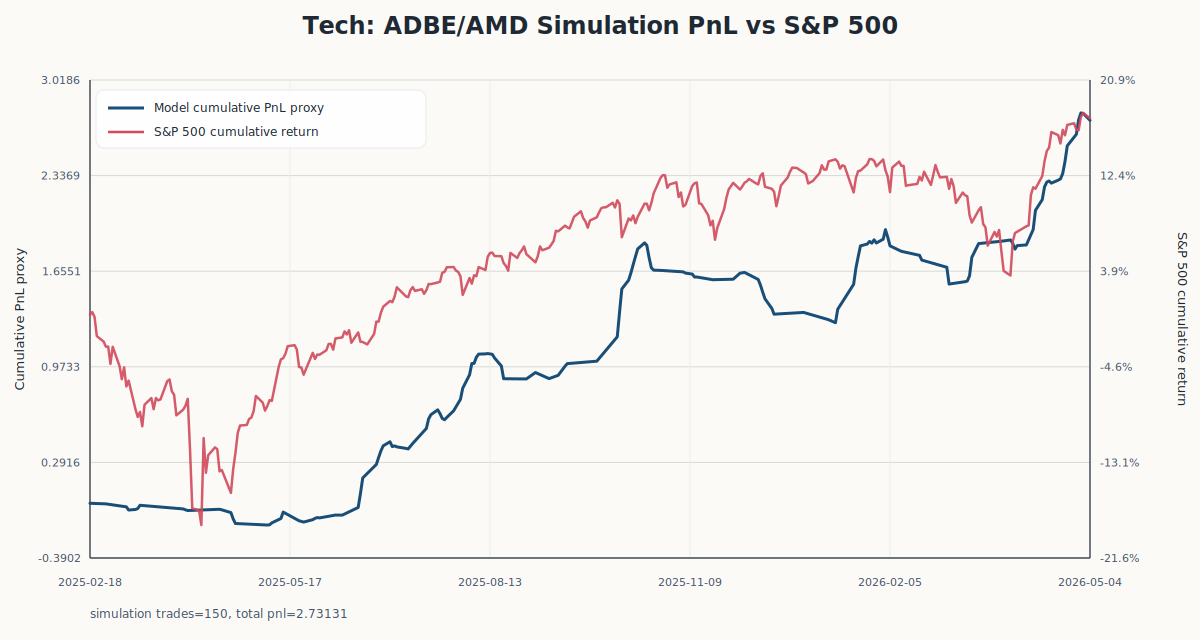

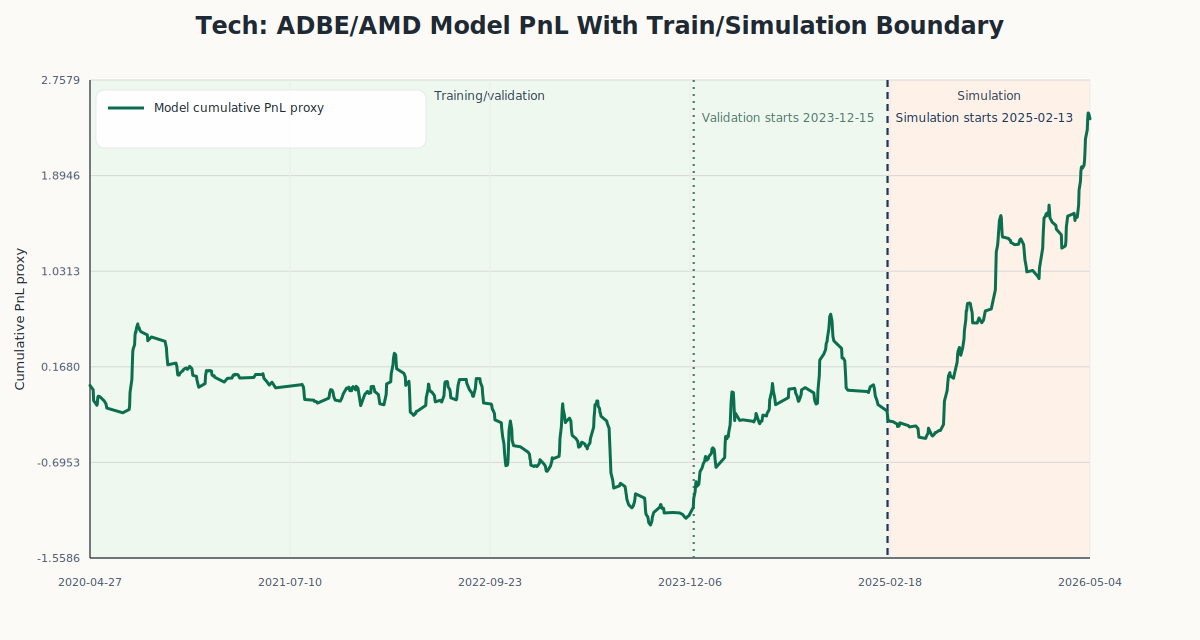

In [16]:
display_sector_result("Tech")

### Financials

Run this cell after the full scan to display the best pair and its two graphs for the Financials sector.

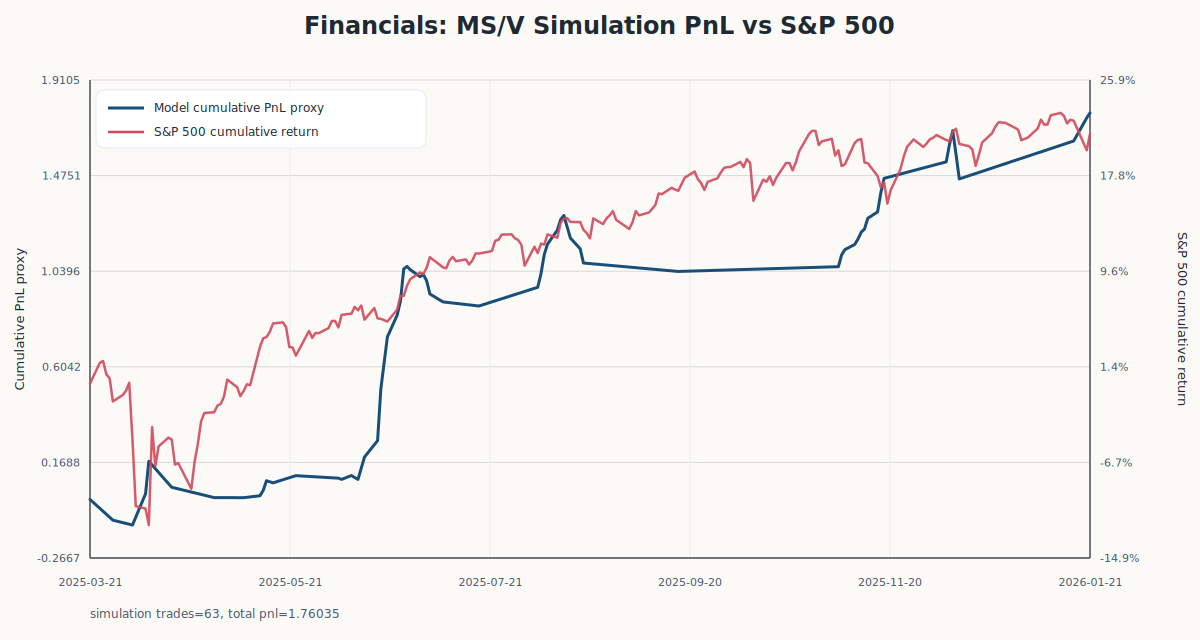

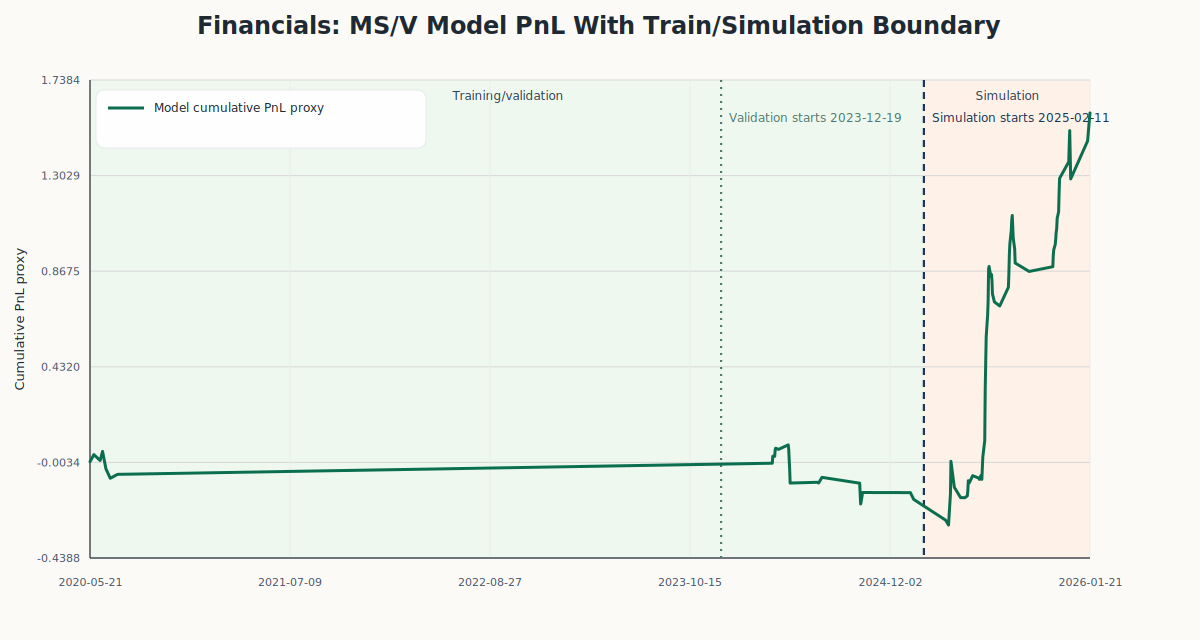

In [17]:
display_sector_result("Financials")

### Consumer_Disc

Run this cell after the full scan to display the best pair and its two graphs for the Consumer_Disc sector.

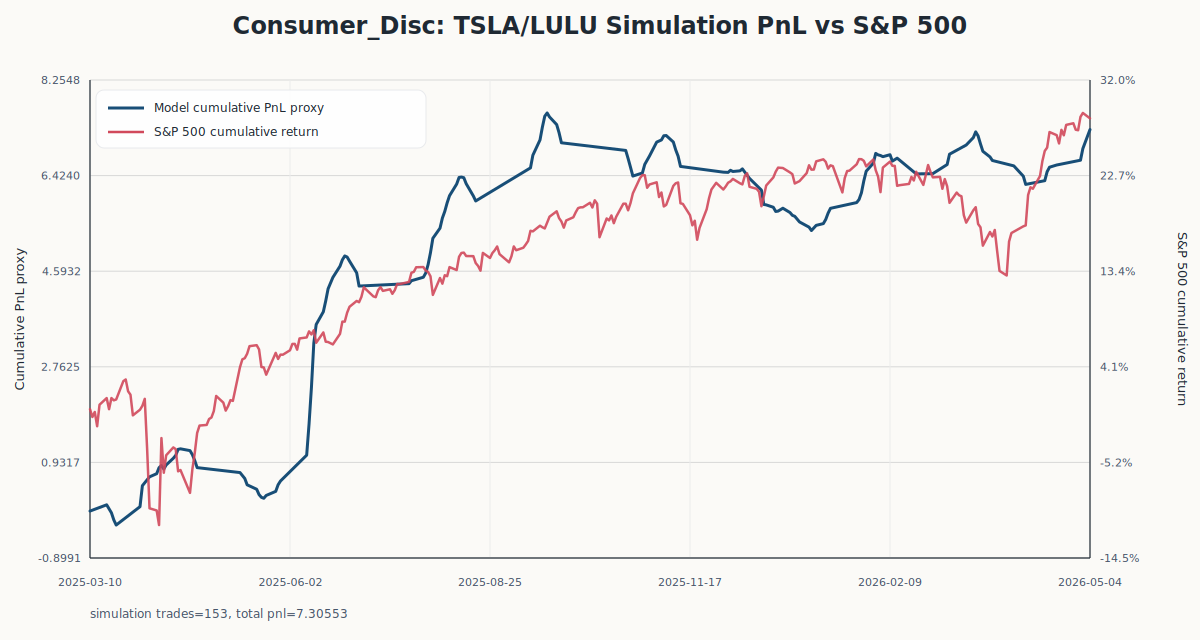

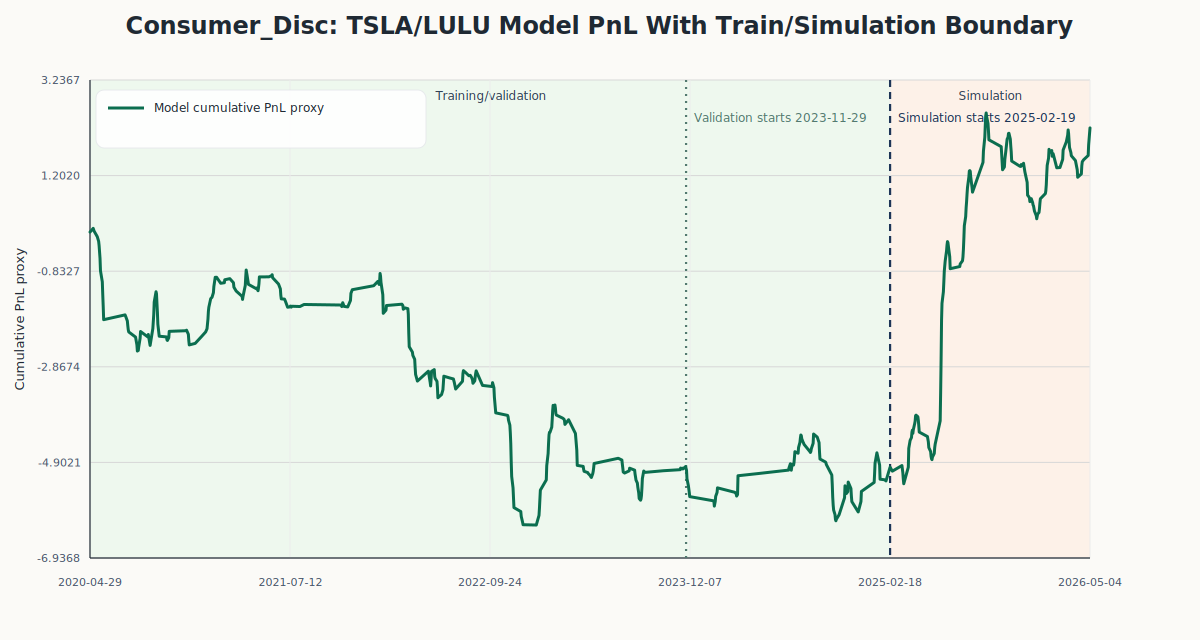

In [18]:
display_sector_result("Consumer_Disc")

### Industrials

Run this cell after the full scan to display the best pair and its two graphs for the Industrials sector.

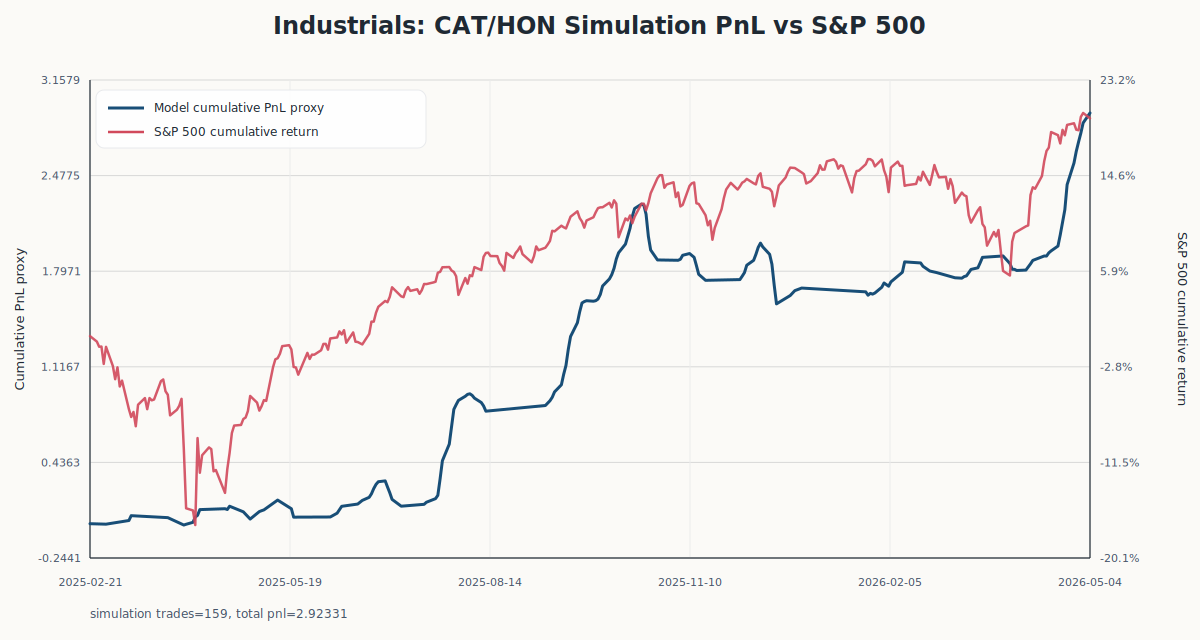

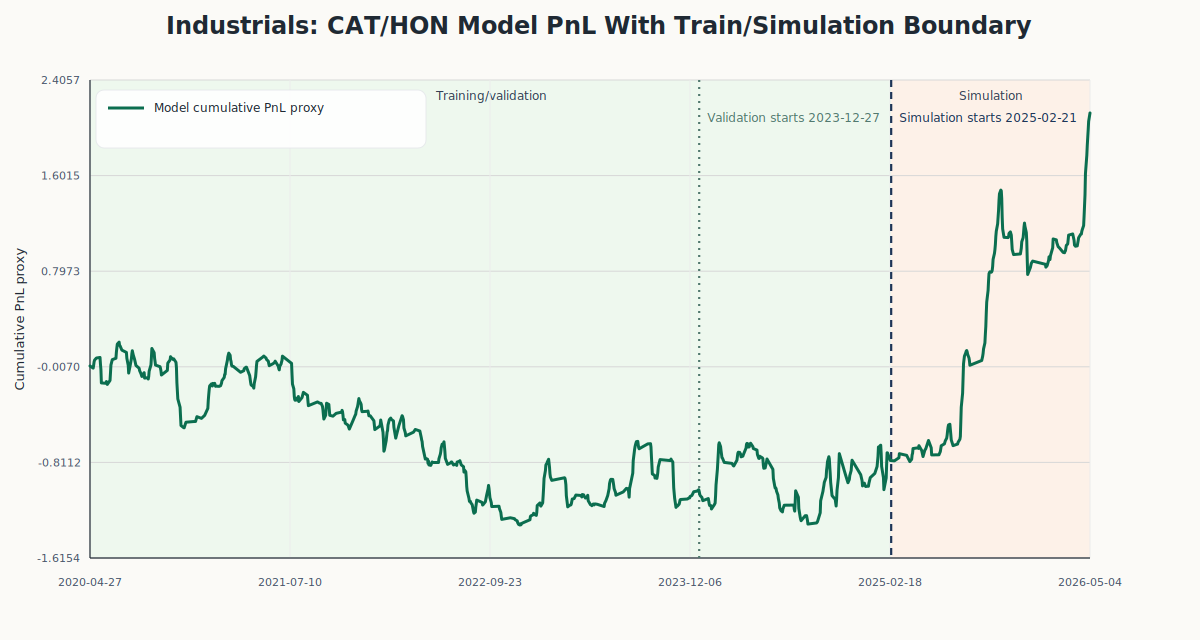

In [19]:
display_sector_result("Industrials")

### Utilities

Run this cell after the full scan to display the best pair and its two graphs for the Utilities sector.

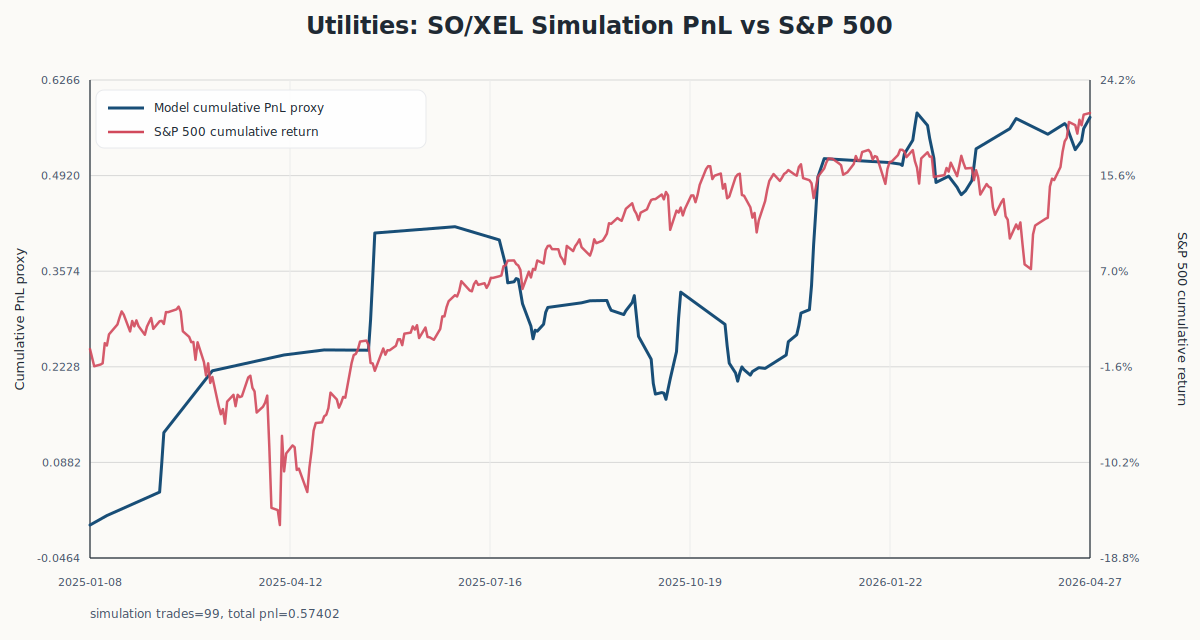

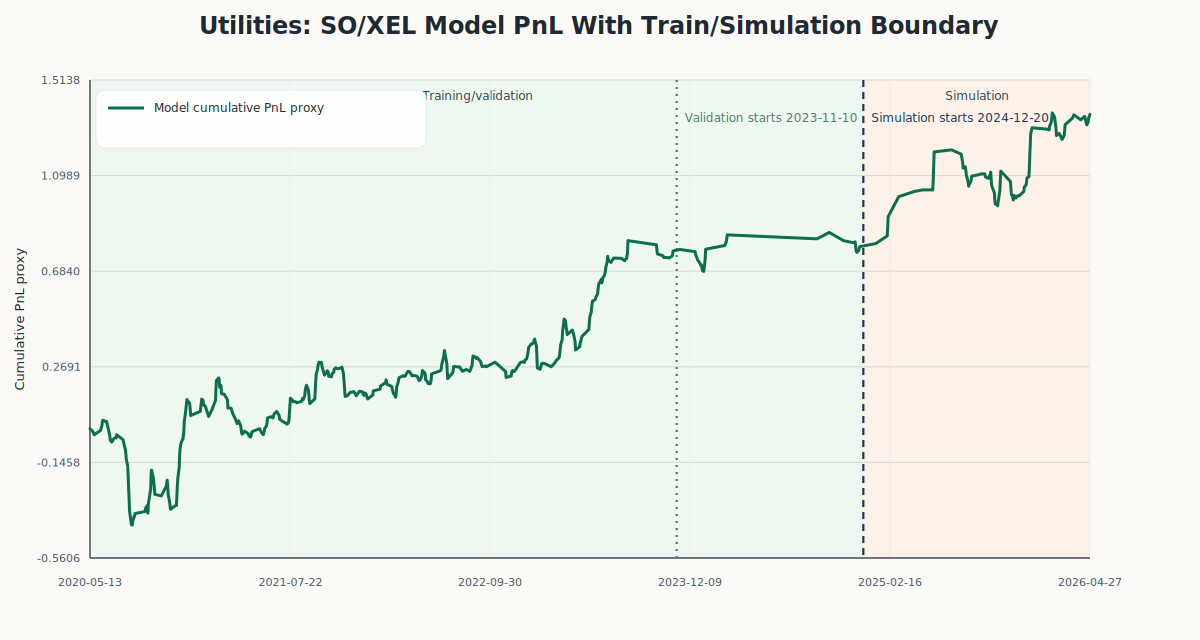

In [20]:
display_sector_result("Utilities")

### Healthcare

Run this cell after the full scan to display the best pair and its two graphs for the Healthcare sector.

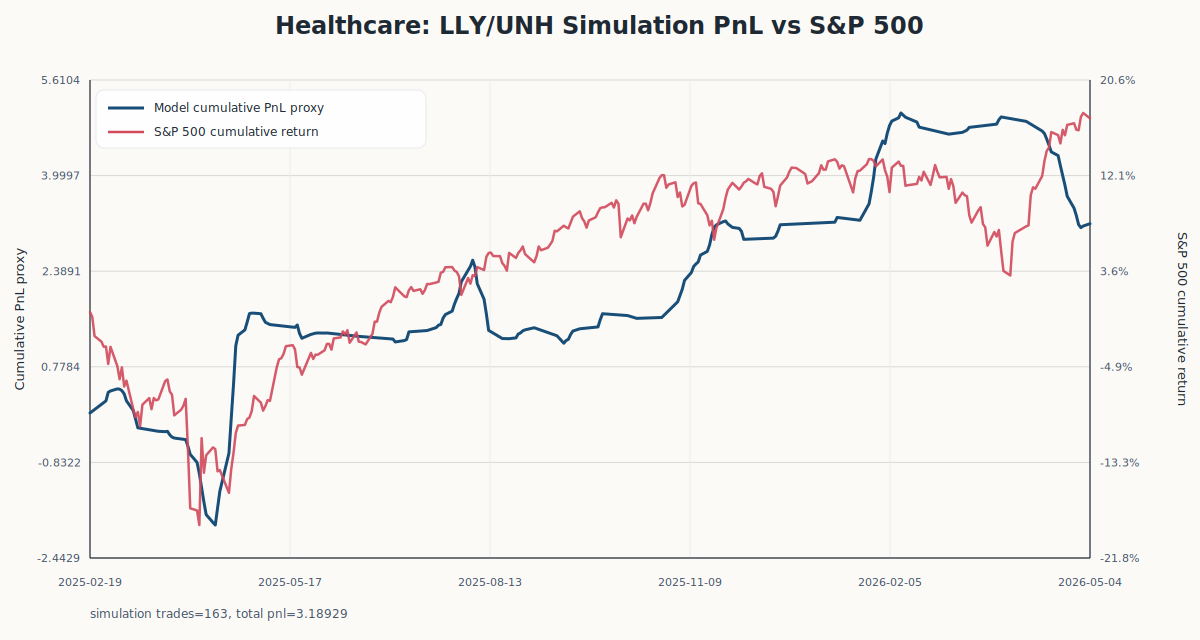

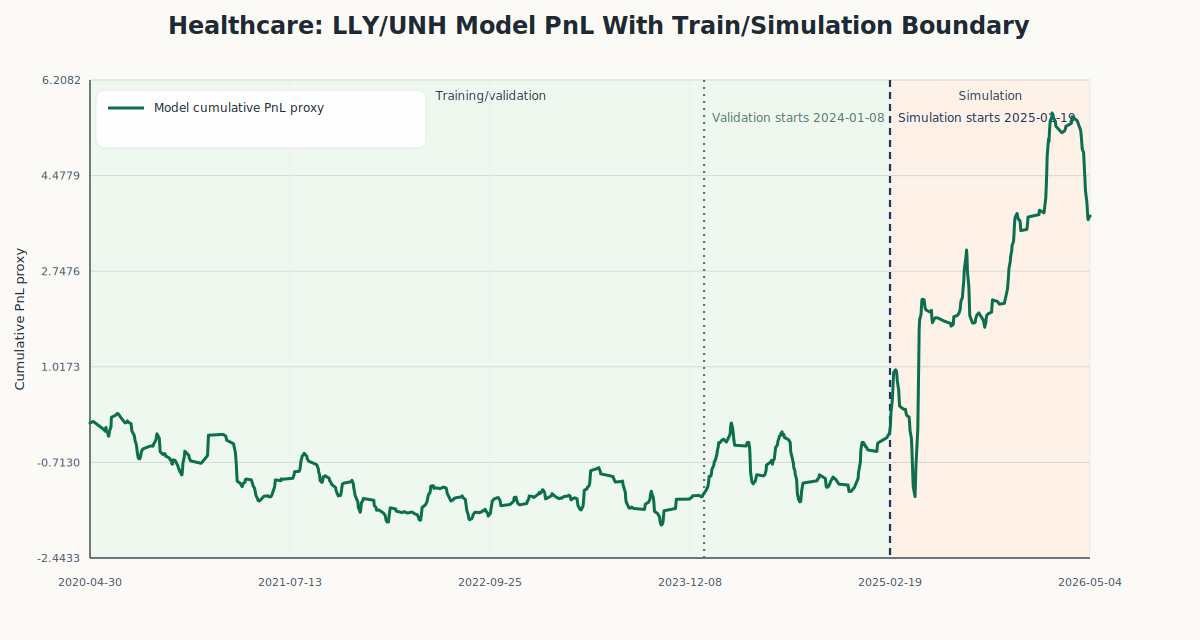

In [21]:
display_sector_result("Healthcare")

### Energy

Run this cell after the full scan to display the best pair and its two graphs for the Energy sector.

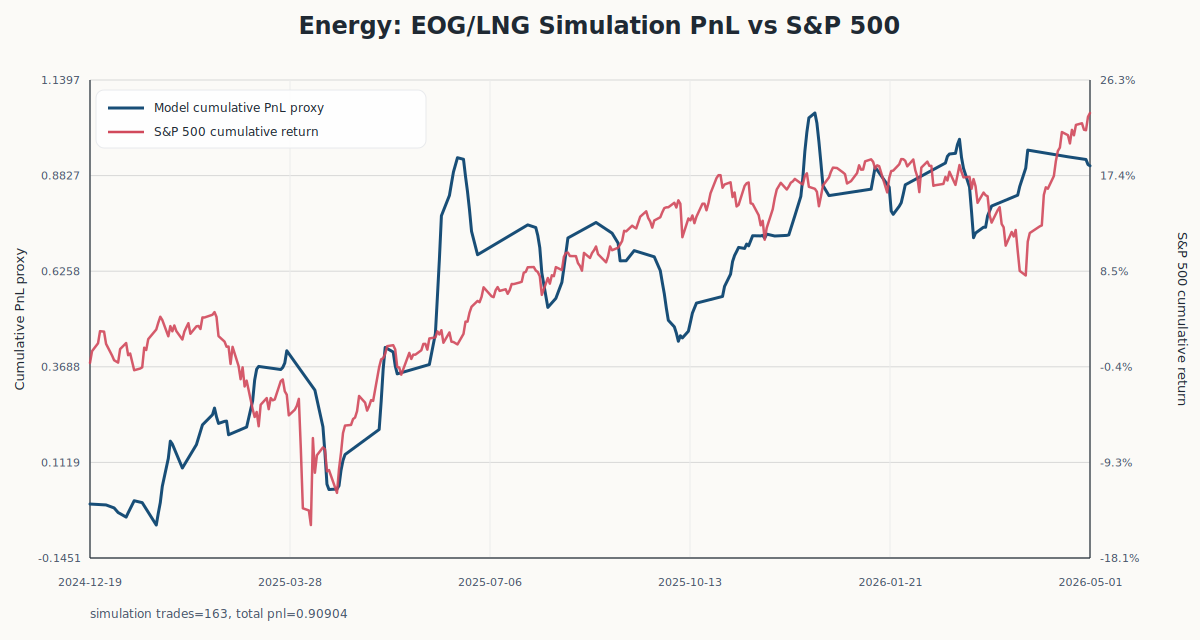

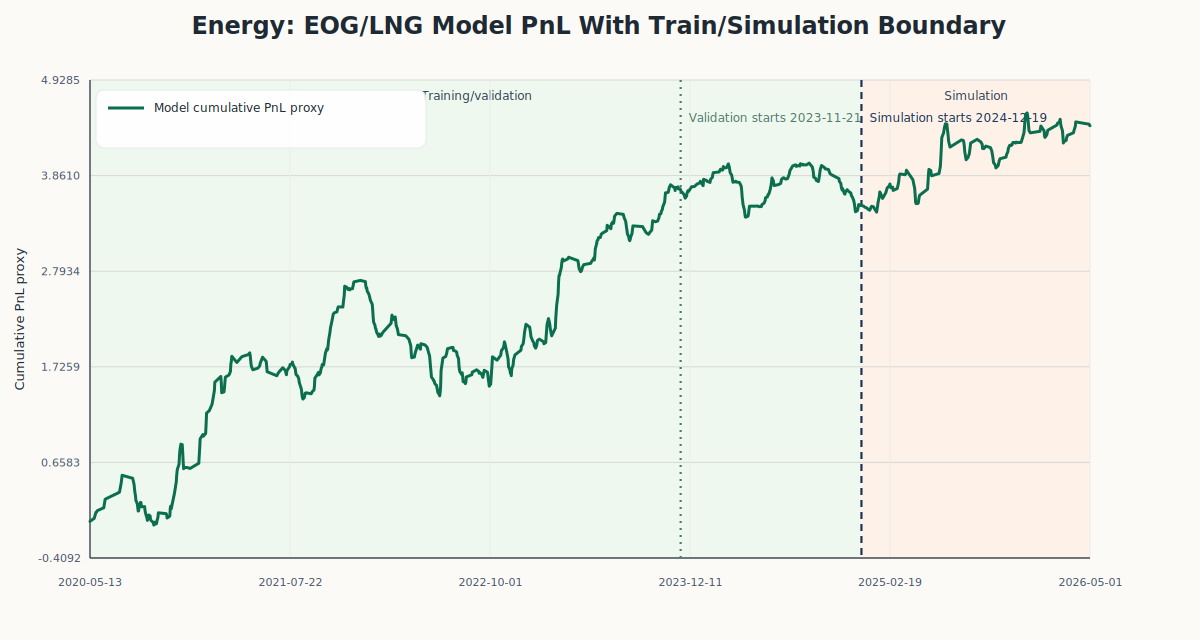

In [22]:
display_sector_result("Energy")

### Consumer_Staples

Run this cell after the full scan to display the best pair and its two graphs for the Consumer_Staples sector.

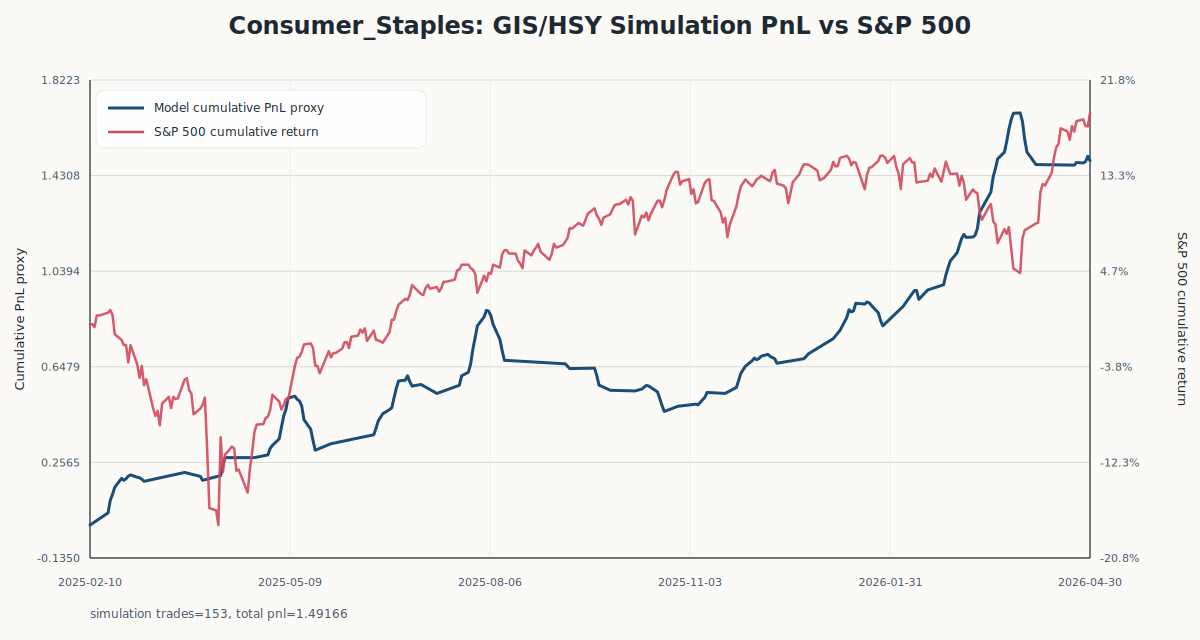

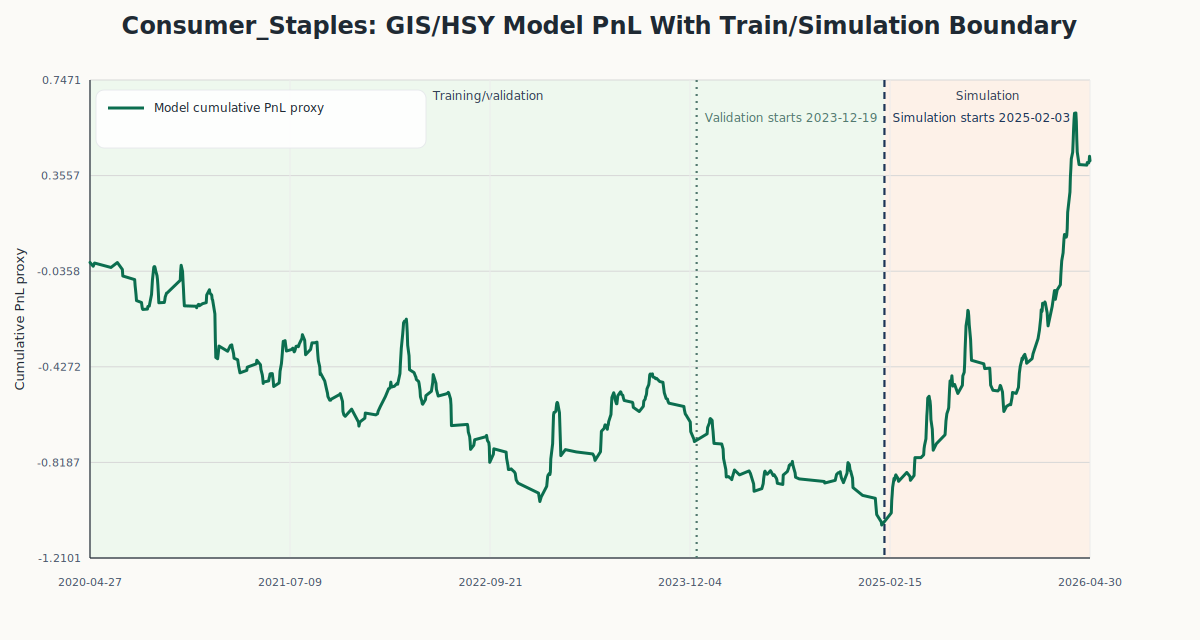

In [23]:
display_sector_result("Consumer_Staples")

### Real_Estate

Run this cell after the full scan to display the best pair and its two graphs for the Real_Estate sector.

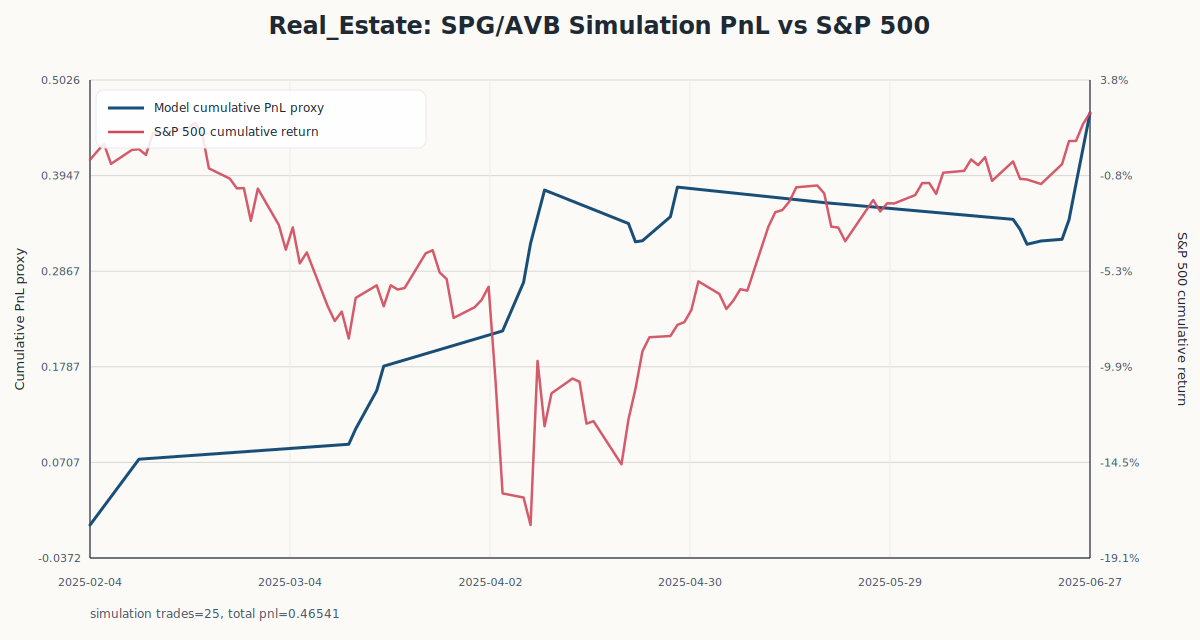

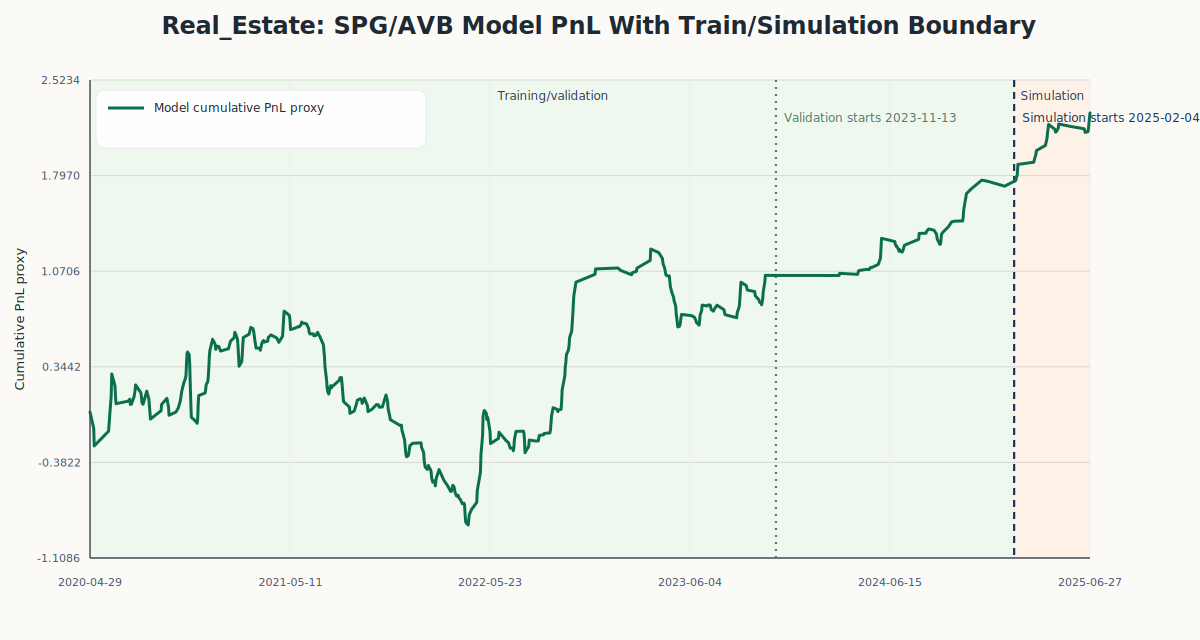

In [24]:
display_sector_result("Real_Estate")

### Communications

Run this cell after the full scan to display the best pair and its two graphs for the Communications sector.

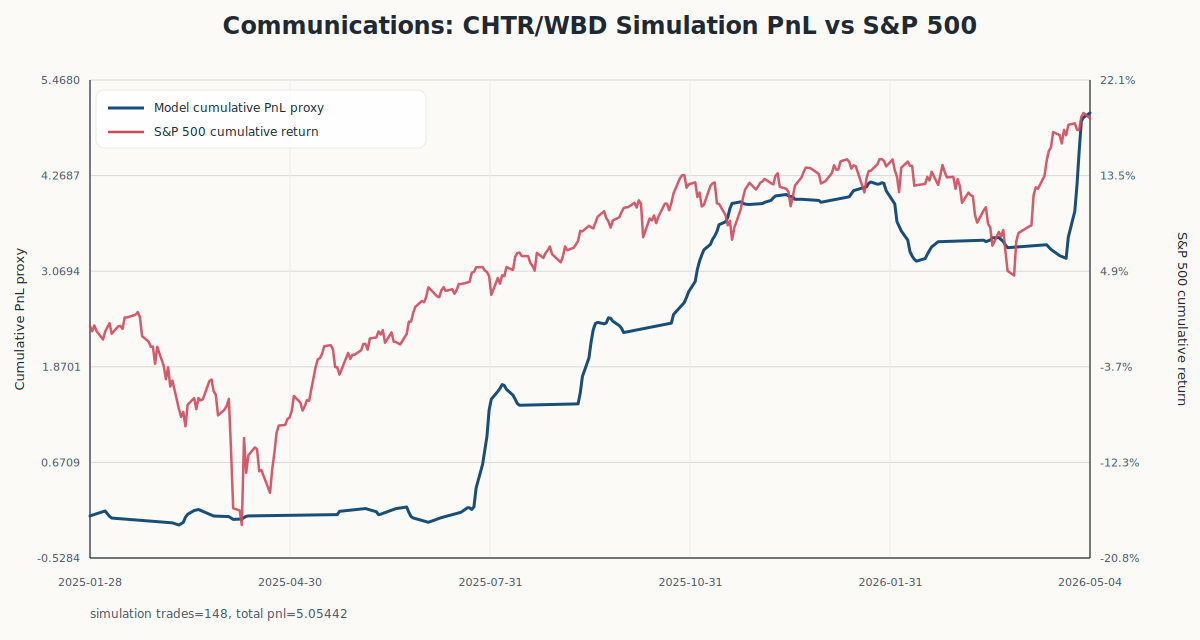

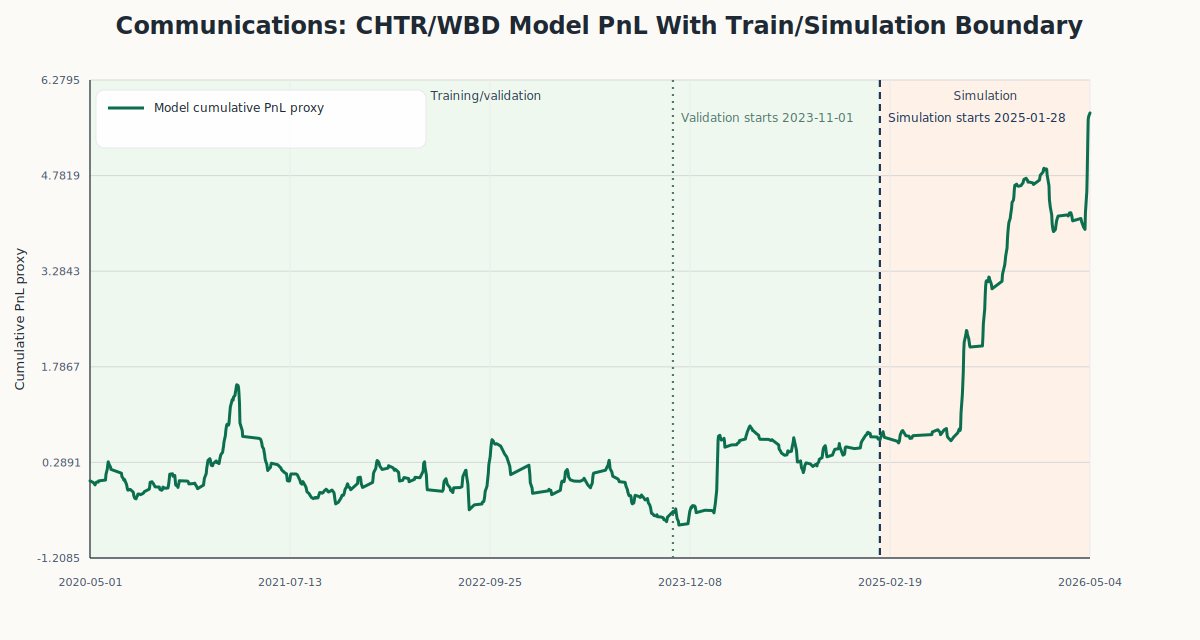

In [25]:
display_sector_result("Communications")